In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
import os

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error

import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

SEED = 42
np.random.seed(SEED)

print('Imported')
print(f'XGBoost:  {xgb.__version__}')
print(f'LightGBM: {lgb.__version__}')

Imported
XGBoost:  3.1.3
LightGBM: 4.6.0


In [2]:
X_train = pd.read_csv('data/processed/X_train.csv')
X_test  = pd.read_csv('data/processed/X_test.csv')
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
test_id = pd.read_csv('data/test.csv')['Id']

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'y_train: {y_train.shape}  (log1p шкала)')
print(f'\ny_train stats:')
print(y_train.describe().round(4))

X_train: (1458, 94)
X_test:  (1459, 94)
y_train: (1458,)  (log1p шкала)

y_train stats:
count   1458.0000
mean      12.0240
std        0.3997
min       10.4603
25%       11.7747
50%       12.0015
75%       12.2737
max       13.5345
Name: SalePrice_log, dtype: float64


In [3]:
# K-fold cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=SEED)

def rmsle_cv(model, X=X_train, y=y_train, cv=kf):
    """Returns the RMSLE via cross-validation (neg_mean_squared_error → sqrt)."""
    scores = cross_val_score(
        model, X, y,
        scoring='neg_mean_squared_error',
        cv=cv, n_jobs=-1
    )
    rmse = np.sqrt(-scores)
    return rmse

def print_score(name, scores):
    print(f'{name:30s}  RMSLE = {scores.mean():.5f}  (±{scores.std():.5f})')

print('Utilities ready')

Utilities ready


In [4]:
ridge = make_pipeline(RobustScaler(), Ridge(alpha=10, random_state=SEED))

score_ridge = rmsle_cv(ridge)
print_score('Ridge (alpha=10)', score_ridge)

Ridge (alpha=10)                RMSLE = 0.11823  (±0.01386)


In [5]:
lasso = make_pipeline(RobustScaler(), Lasso(alpha=0.0005, max_iter=10000, random_state=SEED))

score_lasso = rmsle_cv(lasso)
print_score('Lasso (alpha=0.0005)', score_lasso)

Lasso (alpha=0.0005)            RMSLE = 0.11803  (±0.01379)


In [6]:
enet = make_pipeline(
    RobustScaler(),
    ElasticNet(alpha=0.0005, l1_ratio=0.9, max_iter=10000, random_state=SEED)
)

score_enet = rmsle_cv(enet)
print_score('ElasticNet', score_enet)

ElasticNet                      RMSLE = 0.11797  (±0.01375)


In [7]:
xgb_model = xgb.XGBRegressor(
    n_estimators      = 2000,
    learning_rate     = 0.05,
    max_depth         = 4,
    min_child_weight  = 1,
    subsample         = 0.7,
    colsample_bytree  = 0.7,
    gamma             = 0,
    reg_alpha         = 0.0,
    reg_lambda        = 1.0,
    n_jobs            = -1,
    random_state      = SEED,
    verbosity         = 0
)

score_xgb = rmsle_cv(xgb_model)
print_score('XGBoost', score_xgb)

XGBoost                         RMSLE = 0.11518  (±0.01173)


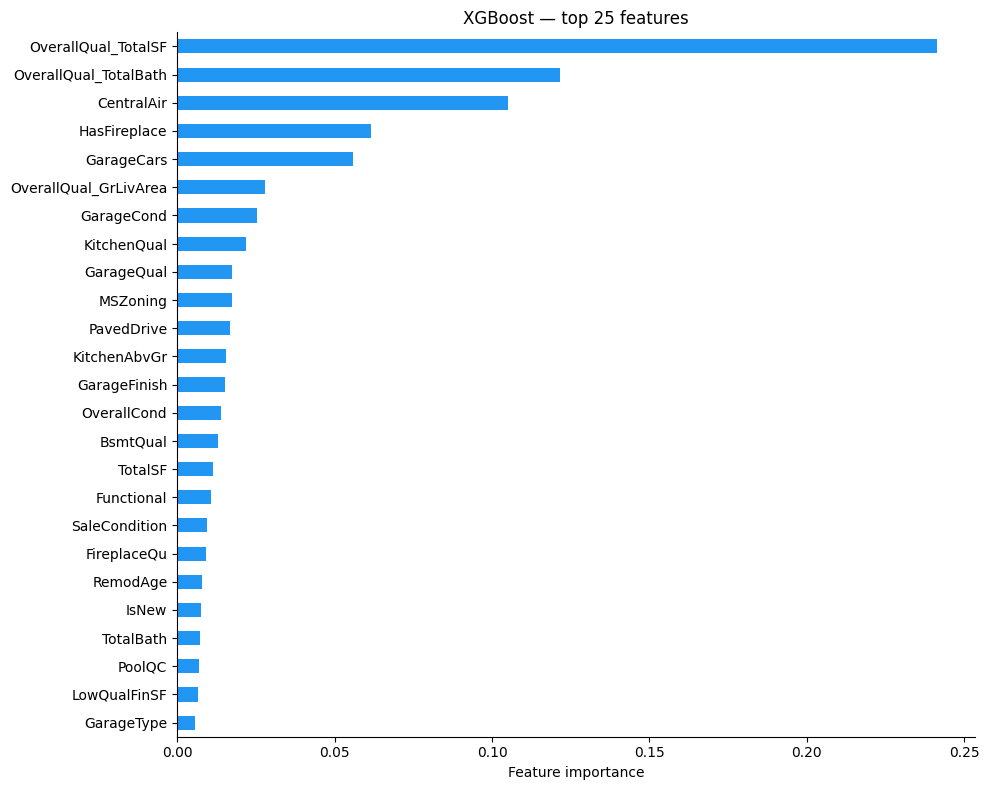

In [8]:
# Feature importance XGBoost
xgb_model.fit(X_train, y_train)

xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
xgb_importance.head(25).sort_values().plot(kind='barh', ax=ax, color='#2196F3')
ax.set_title('XGBoost — top 25 features')
ax.set_xlabel('Feature importance')
plt.tight_layout()
plt.show()

In [9]:
lgb_model = lgb.LGBMRegressor(
    n_estimators      = 3000,
    learning_rate     = 0.05,
    num_leaves        = 31,
    max_depth         = -1,
    min_child_samples = 20,
    subsample         = 0.7,
    subsample_freq    = 1,
    colsample_bytree  = 0.7,
    reg_alpha         = 0.0,
    reg_lambda        = 0.0,
    n_jobs            = -1,
    random_state      = SEED,
    verbose           = -1
)

score_lgb = rmsle_cv(lgb_model)
print_score('LightGBM', score_lgb)

LightGBM                        RMSLE = 0.12202  (±0.01353)


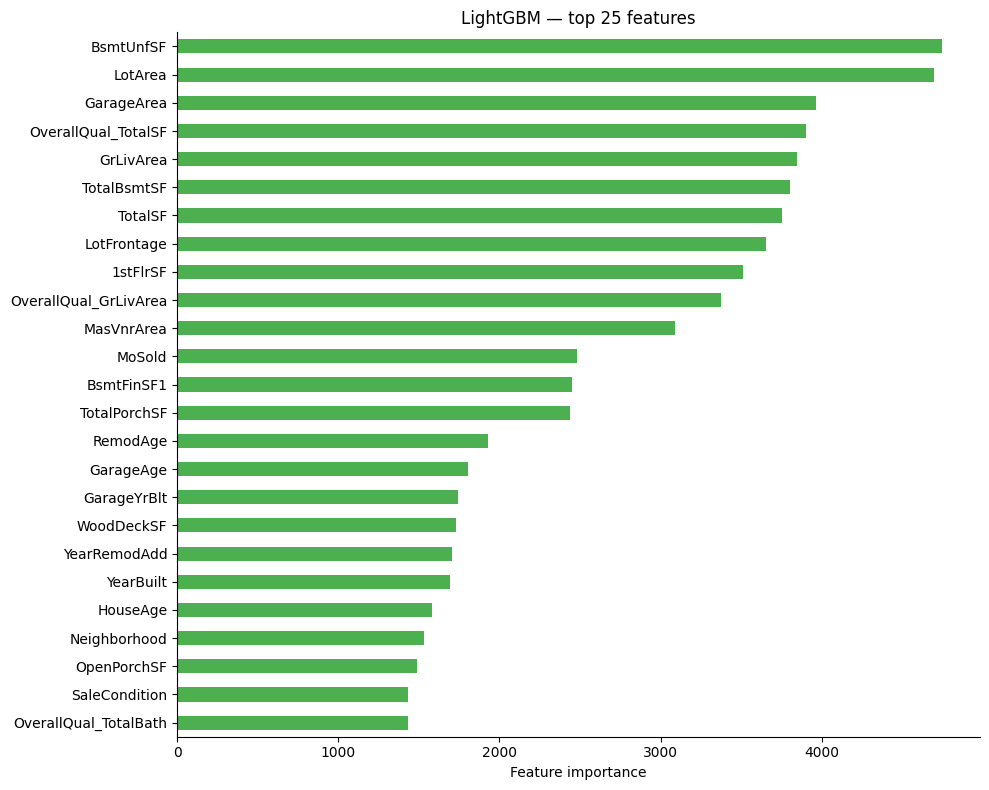

In [10]:
# Feature importance LightGBM
lgb_model.fit(X_train, y_train)

lgb_importance = pd.Series(
    lgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
lgb_importance.head(25).sort_values().plot(kind='barh', ax=ax, color='#4CAF50')
ax.set_title('LightGBM — top 25 features')
ax.set_xlabel('Feature importance')
plt.tight_layout()
plt.show()

Comparing models (10-fold CV RMSLE):
--------------------------------------------------
XGBoost                         RMSLE = 0.11518  (±0.01173)
ElasticNet                      RMSLE = 0.11797  (±0.01375)
Lasso                           RMSLE = 0.11803  (±0.01379)
Ridge                           RMSLE = 0.11823  (±0.01386)
LightGBM                        RMSLE = 0.12202  (±0.01353)


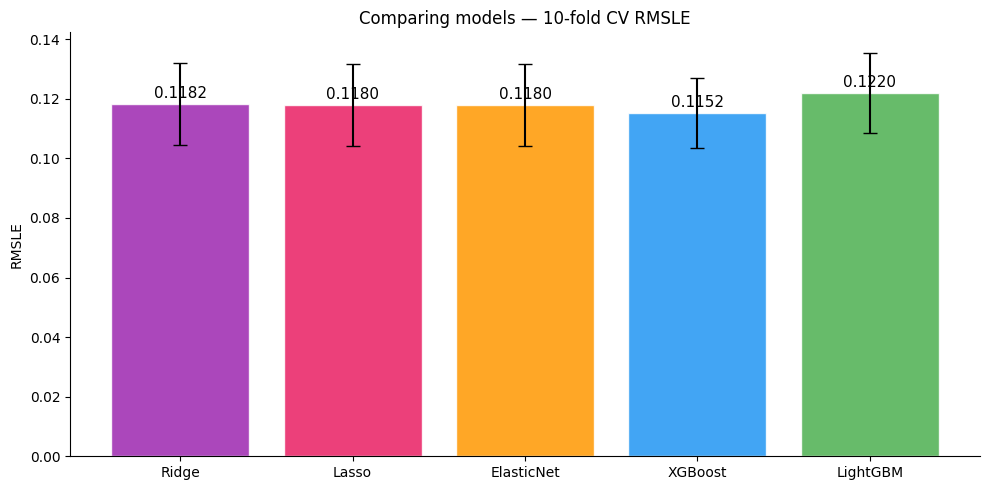

In [11]:
results = {
    'Ridge':      score_ridge,
    'Lasso':      score_lasso,
    'ElasticNet': score_enet,
    'XGBoost':    score_xgb,
    'LightGBM':   score_lgb,
}

print('Comparing models (10-fold CV RMSLE):')
print('-' * 50)
for name, scores in sorted(results.items(), key=lambda x: x[1].mean()):
    print_score(name, scores)

# Визуализация
fig, ax = plt.subplots(figsize=(10, 5))
means  = [s.mean() for s in results.values()]
stds   = [s.std()  for s in results.values()]
names  = list(results.keys())
colors = ['#9C27B0', '#E91E63', '#FF9800', '#2196F3', '#4CAF50']

bars = ax.bar(names, means, yerr=stds, capsize=5,
              color=colors, alpha=0.85, edgecolor='white')
ax.set_ylabel('RMSLE')
ax.set_title('Comparing models — 10-fold CV RMSLE')

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{mean:.4f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

In [12]:
# Selecting blending weights via cross-validation on out-of-focus predictions

def get_oof_predictions(model, X, y, cv):
    """Out-of-fold predictions for evaluating blending."""
    oof = np.zeros(len(y))
    for train_idx, val_idx in cv.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr        = y.iloc[train_idx]
        model.fit(X_tr, y_tr)
        oof[val_idx] = model.predict(X_val)
    return oof

oof_ridge = get_oof_predictions(ridge,     X_train, y_train, kf)
oof_xgb   = get_oof_predictions(xgb_model, X_train, y_train, kf)
oof_lgb   = get_oof_predictions(lgb_model, X_train, y_train, kf)
print('OOF')

OOF


In [13]:
best_rmsle = np.inf
best_w     = None

for w_xgb in np.arange(0.0, 1.05, 0.05):
    for w_lgb in np.arange(0.0, 1.05 - w_xgb, 0.05):
        w_ridge = round(1.0 - w_xgb - w_lgb, 10)
        if w_ridge < 0:
            continue
        blend = w_xgb * oof_xgb + w_lgb * oof_lgb + w_ridge * oof_ridge
        rmsle = np.sqrt(mean_squared_error(y_train, blend))
        if rmsle < best_rmsle:
            best_rmsle = rmsle
            best_w     = (round(w_xgb, 2), round(w_lgb, 2), round(w_ridge, 2))

print(f'Best weights (XGBoost, LightGBM, Ridge):')
print(f'  XGBoost = {best_w[0]}')
print(f'  LightGBM = {best_w[1]}')
print(f'  Ridge    = {best_w[2]}')
print(f'  RMSLE on OOF = {best_rmsle:.5f}')

Best weights (XGBoost, LightGBM, Ridge):
  XGBoost = 0.55
  LightGBM = 0.0
  Ridge    = 0.45
  RMSLE on OOF = 0.11200


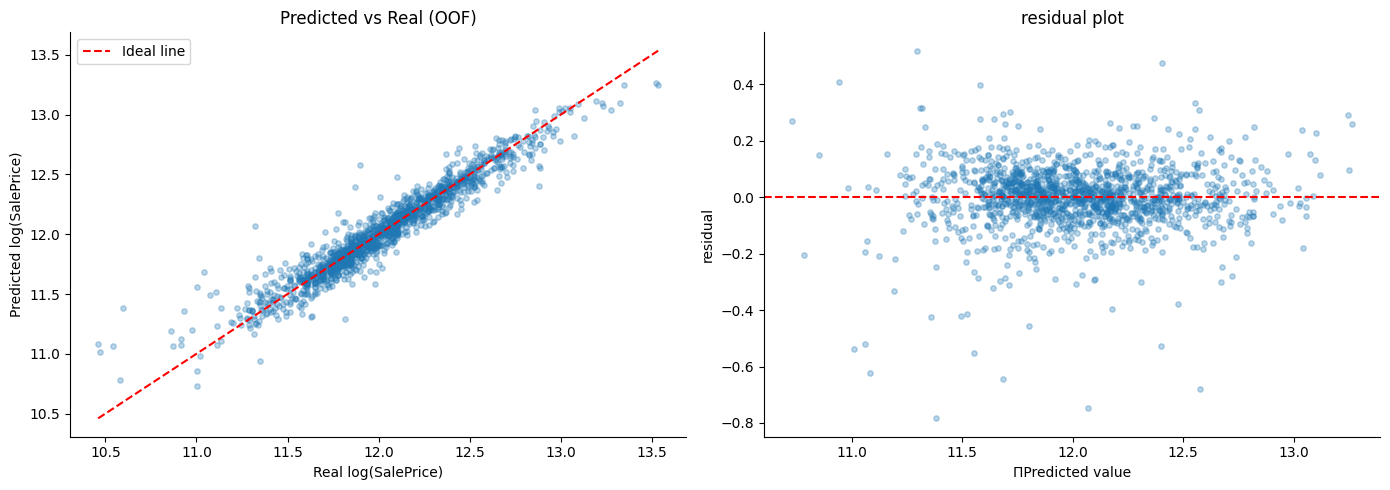

Final RMSLE for blending: 0.11200


In [14]:
# Visualization: Blending predictions vs. actual values
w_xgb, w_lgb, w_ridge = best_w
oof_blend = w_xgb * oof_xgb + w_lgb * oof_lgb + w_ridge * oof_ridge
residuals = y_train.values - oof_blend

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_train, oof_blend, alpha=0.3, s=15)
lims = [y_train.min(), y_train.max()]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Ideal line')
axes[0].set_xlabel('Real log(SalePrice)')
axes[0].set_ylabel('Predicted log(SalePrice)')
axes[0].set_title('Predicted vs Real (OOF)')
axes[0].legend()

# Residuals
axes[1].scatter(oof_blend, residuals, alpha=0.3, s=15)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('ПPredicted value')
axes[1].set_ylabel('residual')
axes[1].set_title('residual plot')

plt.tight_layout()
plt.show()

print(f'Final RMSLE for blending: {best_rmsle:.5f}')

In [15]:
ridge.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)
lgb_model.fit(X_train, y_train)

print('Models fitted')

Models fitted


In [16]:
pred_ridge = ridge.predict(X_test)
pred_xgb   = xgb_model.predict(X_test)
pred_lgb   = lgb_model.predict(X_test)

# Blending with the found weights
pred_blend = w_xgb * pred_xgb + w_lgb * pred_lgb + w_ridge * pred_ridge

# Inverse transformation: expm1 returns the original scale
pred_final = np.expm1(pred_blend)

print(f'Preds ready: {len(pred_final)} values')
print(f'Price range: ${pred_final.min():,.0f} — ${pred_final.max():,.0f}')
print(f'Median price: ${np.median(pred_final):,.0f}')

Preds ready: 1459 values
Price range: $46,786 — $770,636
Median price: $157,075


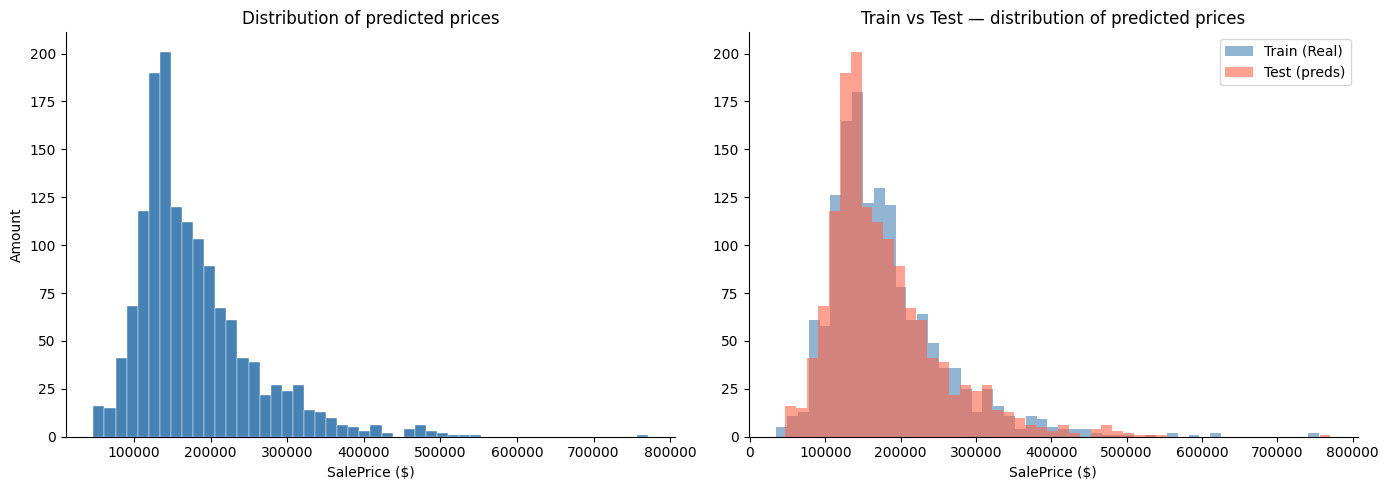

In [17]:
# Distribution of predicted prices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(pred_final, bins=50, edgecolor='white', linewidth=0.3, color='steelblue')
axes[0].set_title('Distribution of predicted prices')
axes[0].set_xlabel('SalePrice ($)')
axes[0].set_ylabel('Amount')

# Comparison with train
train_orig = pd.read_csv('data/train.csv')
axes[1].hist(train_orig['SalePrice'], bins=50, alpha=0.6, label='Train (Real)', color='steelblue')
axes[1].hist(pred_final, bins=50, alpha=0.6, label='Test (preds)', color='tomato')
axes[1].set_title('Train vs Test — distribution of predicted prices')
axes[1].set_xlabel('SalePrice ($)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [19]:
import os, joblib

if os.path.exists('models/best_params.pkl'):
    print('Found Optuna params— using them')
    best_params = joblib.load('models/best_params.pkl')
    xgb_model = xgb.XGBRegressor(**best_params['xgb'])
    lgb_model = lgb.LGBMRegressor(**best_params['lgb'])
    ridge     = make_pipeline(RobustScaler(), Ridge(**best_params['ridge'], random_state=SEED))
else:
    print('No optuna optimization found')

# train and fit
ridge.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)
lgb_model.fit(X_train, y_train)

joblib.dump(ridge,     'models/ridge.pkl')
joblib.dump(xgb_model, 'models/xgb_model.pkl')
joblib.dump(lgb_model, 'models/lgb_model.pkl')

Found Optuna params— using them


['models/lgb_model.pkl']